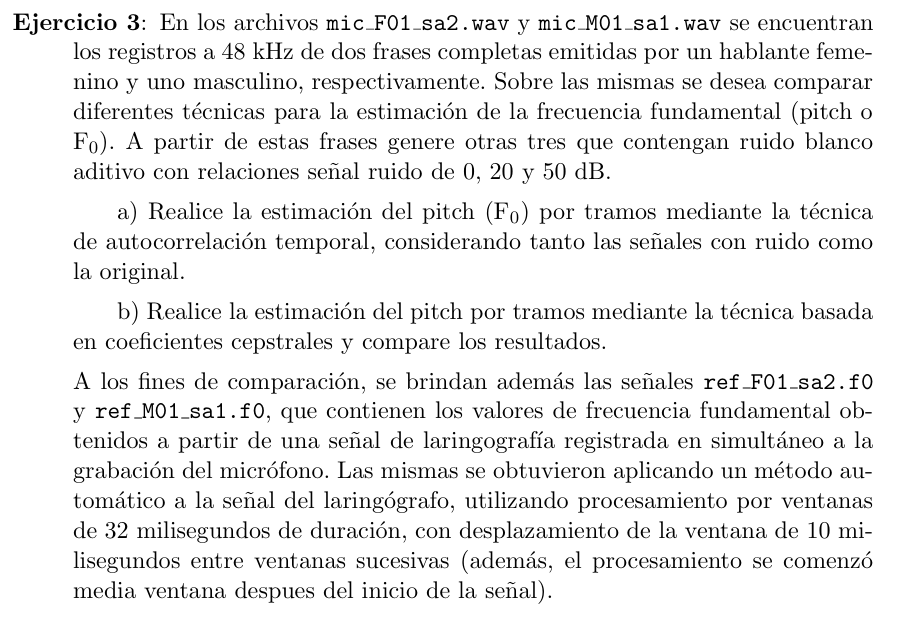

# Inciso a

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, ifft, fftshift

Tamaño original: (350208, 48000)
(350208,)


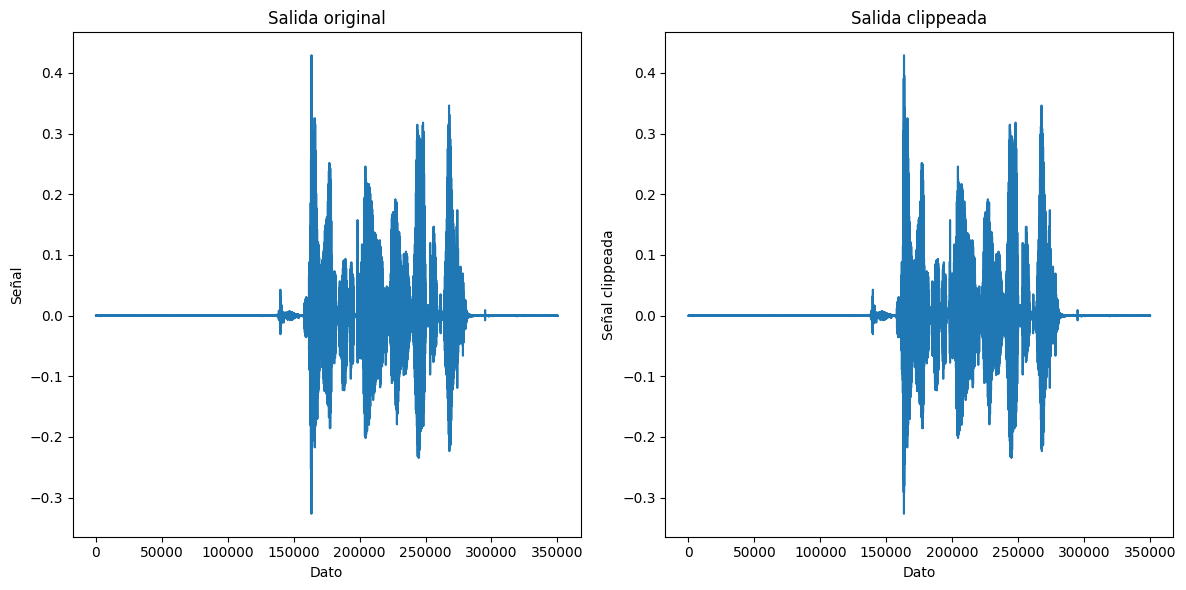

In [ ]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

def agregar_ruido(x, SNR_dB):
    P_signal = np.mean(x**2)

    P_noise = P_signal / (10**(SNR_dB / 10))

    ruido = np.random.randn(len(x))  # ruido blanco N(0,1)
    ruido = ruido / np.sqrt(np.mean(ruido**2))  # normalizar potencia a 1

    ruido = ruido * np.sqrt(P_noise)  # escalar a potencia deseada

    y = x + ruido
    return y

def center_clipping(x, percentage=0.):
    salida = np.zeros_like(x)
    c_norm = np.max(np.abs(x)) * percentage
    for i in range(len(x)):
        dato = x[i]

        if np.abs(dato) < c_norm:
          dato = 0
        elif dato > c_norm:         
          dato -= c_norm
        else:
          dato += c_norm
        salida[i] = dato
    return salida

fs, salida = wavfile.read("PDS_Datos_TP2/mic_F01_sa2.wav")
print(f"Tamaño original: {len(salida), fs}")
#salida = salida[165000:300000] # Para voz femenina
#salida = salida[140000:315000] # Para voz masculina
N = len(salida)
print(salida.shape)

# normalizar según tipo
if salida.dtype == np.int16:
    salida = salida.astype(np.float64)
    salida /= 32768
elif salida.dtype == np.int32:
    salida = salida.astype(np.float64)
    salida /= 2147483648

# 0dB, 20dB, 50dB
salidas = [salida, agregar_ruido(salida, 20), agregar_ruido(salida, 50)]

a = 0.97
q = 0.001
for i in range(len(salidas)):
   # Remoción media
   salidas[i] -= np.mean(salidas[i])

   # Pre-énfasis
   #salidas[i] = salidas[i][1:] - a * salidas[i][:-1]

   # Perturbación
   #salidas[i] = salidas[i] + q * np.random.randn(len(salidas[i]))

   # VENTANA A CADA TRAMO, NO A LA SEÑAL COMPLETA
   #ventana = np.hamming(len(salidas[i]))
   #salidas[i] = salidas[i] * ventana
   #salidas[i] /= np.max(np.abs(salidas[i]))

# Aplicamos center clipping
salidas = [center_clipping(salidas[0]), center_clipping(salidas[1]), center_clipping(salidas[2])]

frecM = 48000

plt.figure(figsize=(12,6))

dom = np.arange(0,len(salida),1) 
plt.subplot(1,2,1)
plt.title("Salida original")
plt.xlabel("Dato")
plt.ylabel("Señal")
plt.plot(dom, salida)

plt.subplot(1,2,2)
plt.title("Salida clippeada")
plt.xlabel("Dato")
plt.ylabel("Señal clippeada")
plt.plot(dom, center_clipping(salida))
plt.tight_layout()
plt.show()

In [ ]:
def obtener_tramos(seniales, duracion_ventana=1536, solapamiento=480, arranque=768):
    tramos = [] # n_señales x 
    cant_tramos = (len(seniales[0]) - duracion_ventana)//solapamiento + 1
    for i in range(len(seniales)):
        tramos_i = []
        for j in range(cant_tramos):
            tramo = seniales[i][arranque + solapamiento * j : arranque + solapamiento * j + duracion_ventana]
            if len(tramo) == duracion_ventana:
                tramos_i.append(tramo)
        tramos.append(tramos_i)
    return np.array(tramos)

tramos = obtener_tramos(salidas)

# Ahora sí, por tramo aplicamos la ventana
for i in range(tramos.shape[0]):
    for j in range(tramos.shape[1]):
        ventana = np.hamming(len(tramos[i,j,:]))
        tramos[i,j,:] = tramos[i,j,:] * ventana
        max_val = np.max(np.abs(tramos[i,j,:]))
        if max_val > 1e-6:
            tramos[i,j,:] /= max_val

print(tramos.shape)

(3, 725, 1536)


In [ ]:
def autocorrelacion_pesada(x, tau, q):
    x_s = x.copy()
    x_m = x.copy()
    N = len(x)

    numerador = 1/(N - np.abs(tau))
    suma_numerador = 0
    for n in range(N-1):
        if q + n < N and q + n + tau < N:
            suma_numerador += x_s[q + n] * x_s[q + n + tau]
    numerador *= suma_numerador

    denominador = 1e-10
    suma_denominador = 0
    for n in range(q, q + N - 1):
        if n+tau < N:
            suma_denominador += np.abs(x_m[n] - x_m[n+tau])
    denominador += suma_denominador

    salida = numerador / denominador
    return salida

def fast_autocorrelacion_pesada(x, tau):
    if tau == 0:
        return 1

    x1 = x[:-tau]
    x2 = x[tau:]

    num = np.dot(x1, x2) / (len(x) - tau)
    den = np.sum(np.abs(x1 - x2)) + 1e-10

    val = num / den

    return val
"""
arranque = 0
fin = 1000

taus = np.arange(0, fin, 1)

APs = []
X_picos = []

for signal in salidas:
    AP = []
    for tau in taus:
        AP.append(fast_autocorrelacion_pesada(signal, tau))
    X_picos.append(np.argmax(AP[arranque:]) + arranque)
    APs.append(AP)
"""
    
F_ceros = [] # 3 señales x cant_tramos
taus = np.arange(1, tramos.shape[2]) 

tau_min = int(frecM/400)
tau_max = int(frecM/80)

for i in range(tramos.shape[0]): # Recorremos cada señal
    F_ceros_i = []
    for j in range(tramos.shape[1]): # Recorremos cada tramo
        tramito = tramos[i,j,:] 
        AP = []
        for tau in taus:
            AP.append(fast_autocorrelacion_pesada(tramito, tau))
        AP = AP / (np.max(np.abs(AP)) + 1e-10)
        AP = np.array(AP)

        AP_recortada = AP[tau_min:tau_max]

        tau = None

        for k in range(tau_min + 1, tau_max - 1):
            if AP[k-1] < AP[k] and AP[k] > AP[k+1] and AP[k] > 0.1:
                tau = k
                break

        if tau is None:
            F_ceros_i.append(0)
            continue
        else:
            F0 = frecM / tau

        if tau < tau_min + 10 or tau > tau_max - 10:
            F0 = 0
     
        if AP[tau] < 0.18:
            F0 = 0

        promedio = np.mean(AP_recortada)
        pico = AP[tau]

        if pico < 2 * promedio:
            F0 = 0

        energia = np.sum(tramito**2)

        if energia < 0.01:
            F0 = 0

        if len(F_ceros_i) > 0:
            prev = F_ceros_i[-1]
            if prev != 0 and abs(F0 - prev) > 50:
                F0 = 0

        F_ceros_i.append(F0)


    F_ceros.append(F_ceros_i)
F_ceros = np.array(F_ceros)

In [ ]:
print(F_ceros.shape)
print(len(taus))

(3, 725)
1535


724
(724,)


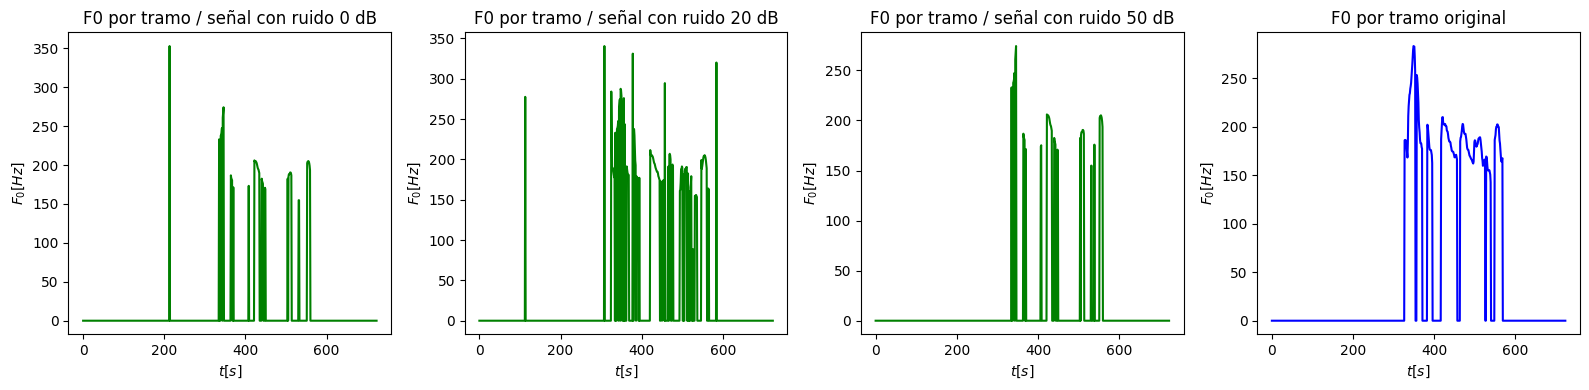

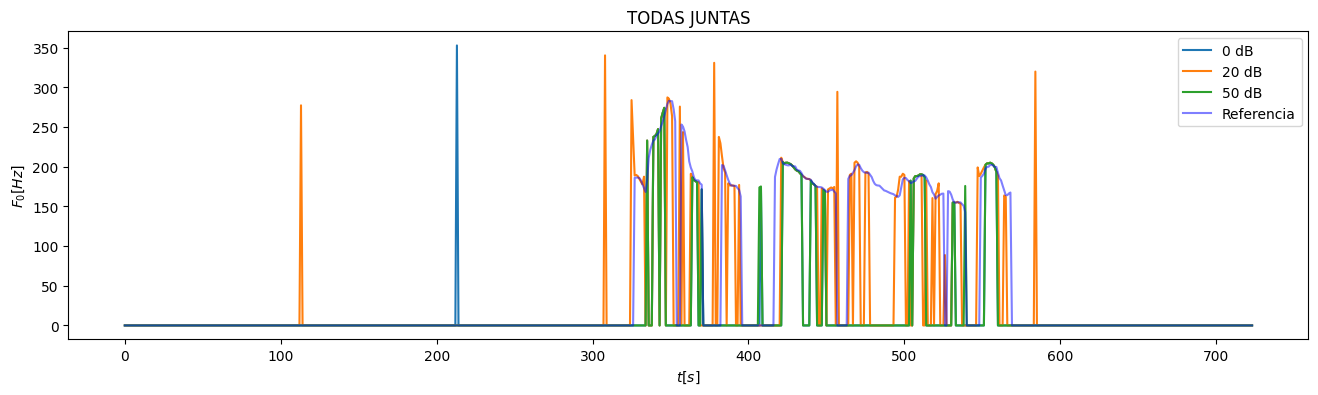

In [ ]:
# Comparemos con lo que nos tira el archivo
data = np.loadtxt("PDS_Datos_TP2/ref_F01_sa2.f0")

f0_ref = data[:, 0]
voiced = data[:, 1]
confianza = data[:, 3]
# ------------------------------------------

ruidos = ['0 dB', '20 dB', '50 dB']
dom = np.arange(F_ceros.shape[1]-1)
print(len(f0_ref))
print(F_ceros[0,:-1].shape)

plt.figure(figsize=(16,4))
for i in range(len(salidas)):
    plt.subplot(1,4,i+1)
    plt.title(f"F0 por tramo / señal con ruido {ruidos[i]}")
    plt.ylabel("$F_0 [Hz]$")
    plt.xlabel("$t [s]$")
    plt.plot(dom, F_ceros[i, :-1], color='green')
plt.subplot(1,4,4)
plt.title(f"F0 por tramo original")
plt.ylabel("$F_0 [Hz]$")
plt.xlabel("$t [s]$")
plt.plot(dom, f0_ref, color="blue")
plt.tight_layout()

plt.figure(figsize=(16,4))
for i in range(len(salidas)):
    plt.title(f"TODAS JUNTAS")
    plt.plot(dom, F_ceros[i, :-1], label = f'{ruidos[i]}')

plt.plot(dom, f0_ref, color="blue", label=f'Referencia', alpha=0.5)
plt.ylabel("$F_0 [Hz]$")
plt.xlabel("$t [s]$")
plt.legend()
plt.show()

# Inciso b

In [ ]:
def extraer_coeficientes_cepstrales(tramo):
    v_tranf = fft(tramo)
    v_real = np.real(v_tranf)
    v_im = np.imag(v_tranf)
    v_norm = np.sqrt(v_real**2 + v_im**2)
    v_tranf = np.log(v_norm + 1e-10)
    v_inv = np.real(ifft(v_tranf))
    return np.array(v_inv)

coefs = []

for i in range(tramos.shape[0]): # Vamos por señal
    coefs_i = []
    for j in range(tramos.shape[1]): # Por tramo
        tramito = tramos[i,j,:]
        coeficientes = extraer_coeficientes_cepstrales(tramito)
        coefs_i.append(coeficientes)
    coefs.append(coefs_i)

coefs = np.array(coefs)
print(coefs.shape)


(3, 725, 1536)


In [ ]:
# Ahora que ya tenemos los coeficientes cepstrales para cada señal y cada tramo
# vamos a buscar picos en el cepstrum (NO en el dominio frecuencial)

F_ceros_cepstrum = []

tau_min = int(frecM / 400)
tau_max = int(frecM / 80)

for i in range(coefs.shape[0]):
    F_ceros_cepstrum_i = []
    for j in range(coefs.shape[1]):
        tramito = coefs[i,j,:]
        tramito[:30] = 0 # Eliminamos la envolvente (quedó separada del pitch por la 
                         # extracción de coefs cepstrales)

        idx = np.argmax(tramito[tau_min:tau_max])
        tau = tau_min + idx

        valor_pico = tramito[tau]
 
    
        if valor_pico > 0.1:   
            F0 = frecM / tau
        else:
            F0 = 0
        
        F_ceros_cepstrum_i.append(F0)

    F_ceros_cepstrum.append(F_ceros_cepstrum_i)

F_ceros_cepstrum = np.array(F_ceros_cepstrum)
print(F_ceros_cepstrum.shape)

(3, 725)


724
(724,)


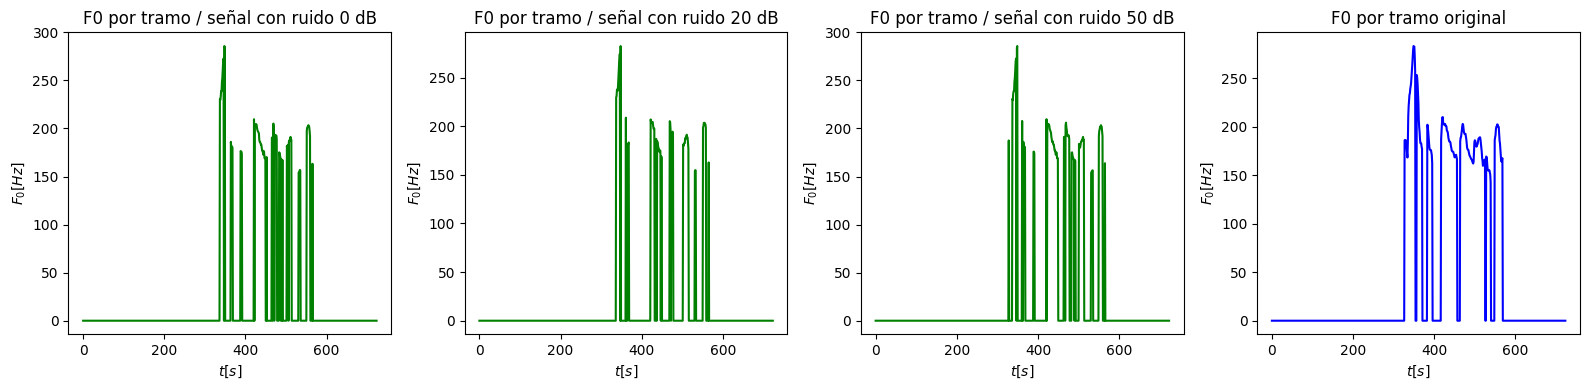

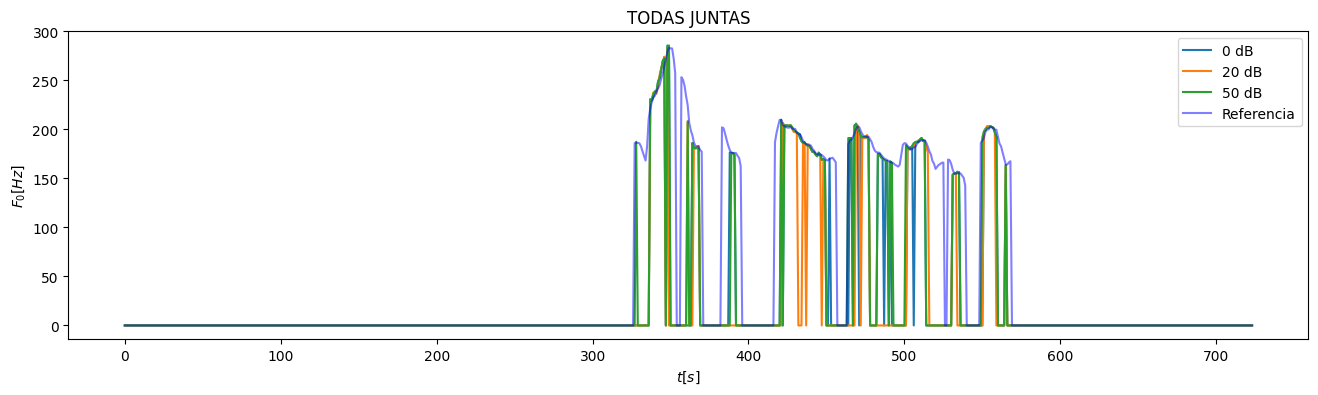

In [ ]:
# Comparemos con lo que nos tira el archivo

ruidos = ['0 dB', '20 dB', '50 dB']
dom = np.arange(F_ceros_cepstrum.shape[1]-1)
print(len(f0_ref))
print(F_ceros_cepstrum[0,:-1].shape)

plt.figure(figsize=(16,4))
for i in range(len(salidas)):
    plt.subplot(1,4,i+1)
    plt.title(f"F0 por tramo / señal con ruido {ruidos[i]}")
    plt.ylabel("$F_0 [Hz]$")
    plt.xlabel("$t [s]$")
    plt.plot(dom, F_ceros_cepstrum[i, :-1], color='green')
plt.subplot(1,4,4)
plt.title(f"F0 por tramo original")
plt.ylabel("$F_0 [Hz]$")
plt.xlabel("$t [s]$")
plt.plot(dom, f0_ref, color="blue")
plt.tight_layout()

plt.figure(figsize=(16,4))
for i in range(len(salidas)):
    plt.title(f"TODAS JUNTAS")
    plt.plot(dom, F_ceros_cepstrum[i, :-1], label = f'{ruidos[i]}')

plt.plot(dom, f0_ref, color="blue", label=f'Referencia', alpha=0.5)
plt.ylabel("$F_0 [Hz]$")
plt.xlabel("$t [s]$")
plt.legend()
plt.show()